This is the Notebook of the second tutorial exercises 

Problem 1) - Monte Carlo integration

In [4]:
import numpy as np
import scipy as scp
import scipy.stats as stats
import matplotlib.pyplot as plt
import math

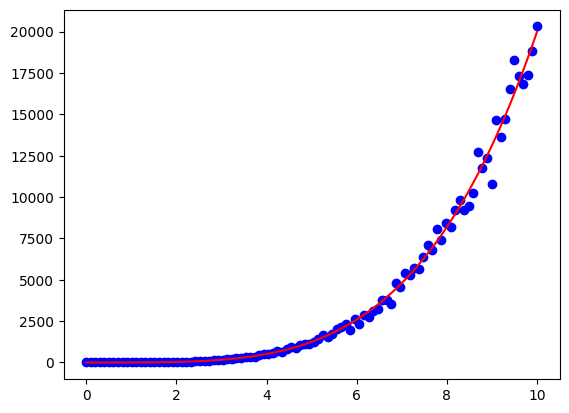

In [5]:
sigma = 1
sample_l = 1000
#now, lets first define our integrand function(total integrand without the p(x) part):

def compute_integral(sigma):
    integrand = np.vectorize(lambda x,sigma: x**3*math.sqrt(math.pi/2)*sigma)   
    #now, let's make a sampling from the destribution:
    sample = abs(np.random.normal(0,sigma, sample_l))
    #print(sample) 
    return np.sum(integrand(sample,sigma)/sample_l)


sigma = np.linspace(0,10,100)
integrals = [compute_integral(value) for value in sigma]
plt.scatter(sigma, integrals, color="blue")
plt.plot(sigma, 2*sigma**4, color="red")



Now, we go down the rabbithole of the distribution of Prussian cavalerists kicked to death by horses

[0.54335087 0.33144403 0.10109043 0.02055505 0.00313465]


<function matplotlib.pyplot.show(close=None, block=None)>

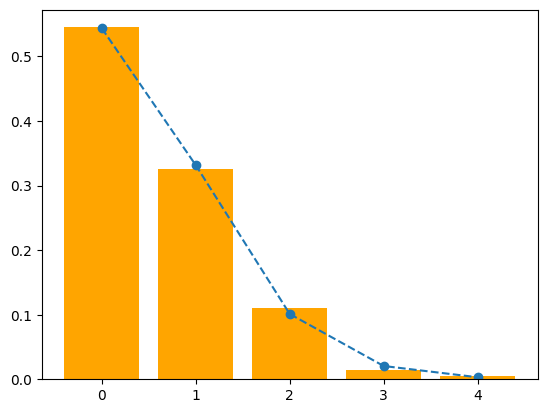

In [6]:
death_by_regiments = np.array([109,65,22,3,1])
regiments = np.array([0,1,2,3,4])

total_deaths = np.sum(death_by_regiments)

mean_deaths_per_reg = np.dot(death_by_regiments,regiments)/total_deaths


poisson = np.vectorize(lambda x: np.e**(-mean_deaths_per_reg)*(mean_deaths_per_reg**x)/math.factorial(x))

plt.bar(regiments,death_by_regiments/total_deaths,color="orange")
plt.plot(regiments, poisson(regiments),marker="o",linestyle="dashed")
print(poisson(regiments))
plt.show

Cloning Quasars assignment

[0.84543478 2.03549147 1.57422745 ... 1.23296249 2.00986481 2.375     ]


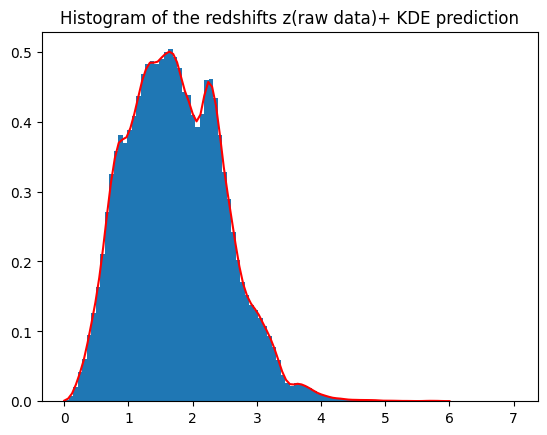

In [7]:
#first import the data from quazar cleaned file

z_clean = np.load(r"C:\Users\Cyber\Documents\VS code\Python\Statistics_meerburg_2026\Data\quasar_redshifts.npz")["z"]
#now as data is importet let's print it out
print(z_clean)

plt.hist(z_clean, bins=100, density=True)

x_range = np.linspace(0,6,100)
kde = stats.gaussian_kde(z_clean)
kde_prediction = kde(x_range)                    
plt.plot(x_range,kde_prediction,color="red")
plt.title("Histogram of the redshifts z(raw data)+ KDE prediction")

#compute the kde here


plt.show()

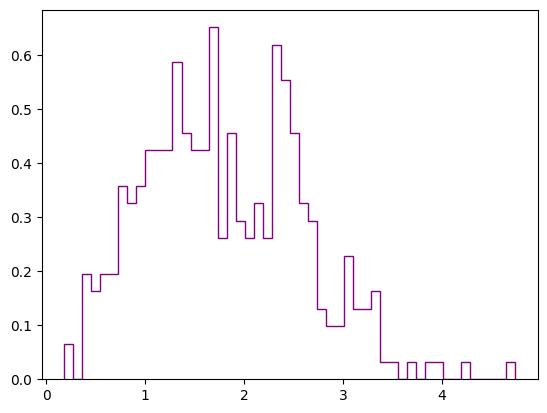

In [33]:
#now let's sample this distribution using the rejection sampling:
kde = stats.gaussian_kde(z_clean)
#number of random points to draw
N=1000
#now we get the x-values in the specified range
x_range = np.linspace(0,6,100)
y_kde = kde(x_range)
#maximum point in the kde function 
y_max = max(y_kde)
#now let's start sampling from the uniform distributions
x_points = np.random.uniform(0,6,N)
y_points = np.random.uniform(0,y_max,N)
#now do the rejection sampling
rejection_sample = x_points[y_points<kde(x_points)]
plt.hist(rejection_sample, bins = 50, density=True, histtype='step',color="purple")
plt.show()


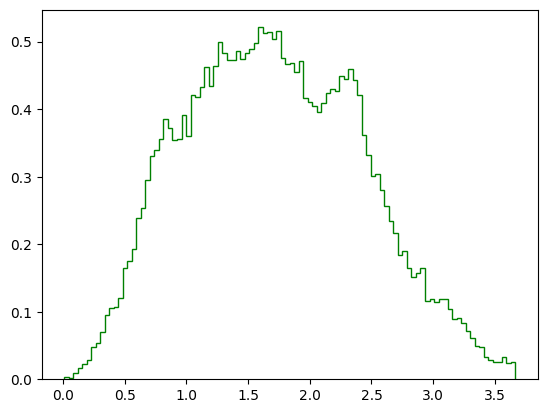

: 

In [ ]:
#inverse transform sampling example on the same distribution
kde = stats.gaussian_kde(z_clean)
x_range = np.linspace(0,6,100)
#compute the cdf using the cumulative integration function of scp
cdf = scp.integrate.cumulative_trapezoid(kde(x_range), x_range, initial=0)
#finally with the generated cdf points we can interpolate the quartile function
quartile_function = scp.interpolate.interp1d(cdf, x_range)
inverse_sample = [quartile_function(np.random.uniform(0,0.99)) for x in range(0,50000)]
plt.hist(inverse_sample,bins = 100, density=True, histtype='step',color="green")
plt.show()
#that's how easy the inverse sampling is
#as you can see it is working